# **Security Breach Analysis**

## Objectives

Security Breach Analysis is a comprehensive data analysis project designed to explore, analyse, and visualise cybersecurity attack data. The project aims to provide valuable insights into security threats, attack patterns, and their impact using various data analysis techniques and visualisations.

## Inputs
This dataset contains cybersecurity attack records, including details such as timestamps, source and destination IP addresses, attack types, severity levels, and geo-location data. The dataset is cleaned and preprocessed to facilitate in-depth analysis and visualisation of security breaches.
Dataset Summary
Total Rows: 40,000
Columns: 25
Missing Data:
Malware Indicators, Alerts/Warnings, Proxy Information, Firewall Logs, and IDS/IPS Alerts have missing values.
Issues Identified:
Timestamp format needs conversion.
Attack Type standardization (case normalization).
Missing values need handling.
Duplicate entries should be removed.


## Outputs
1.	Attacks Over Time – A time series plot showing attack occurrences over time.
2.	Top Source IPs – A bar chart of the most frequent source IP addresses.
3.	Attack Type Distribution – A bar chart showing the frequency of different attack types.
4.	Severity Level Distribution – A pie chart displaying the proportion of attacks by severity.
5.	Traffic Type Analysis – A bar chart showing the distribution of different traffic types.
6.	Anomaly Score Distribution – A Boxplot for anomaly scores.
7.  Geo loacation Analysis - A Map showing distribution of attack types accoriding to severity level.
8.  DDOS filter Analysis - Time Series plot and Heatmap showing filtered count for DDoS attacks.


---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [4]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\mukti\\Desktop\\codeInstitute\\SecurityBreachAnalysis\\SecurityBreachAnalysis'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [5]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [6]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\mukti\\Desktop\\codeInstitute\\SecurityBreachAnalysis'

# Section 1

# ETL pipeline for Security Breach Analysis

The ETL script is designed to clean and transform a cybersecurity attack dataset by handling missing values, standardising data formats, extracting relevant information, and preparing it for further analysis or visualisation.


In [7]:
import pandas as pd  # Library for data manipulation
import numpy as np   # Library for numerical operations

def split_city_state(location):
    """Splits 'Geo-location Data' into City and State, handling missing values."""
    try:
        if pd.isna(location) or ',' not in location:
            return "Unknown", "Unknown"
        city, state = location.rsplit(',', 1)  # Ensures only the last comma is used for splitting
        return city.strip(), state.strip()
    except:
        return "Unknown", "Unknown"

def clean_and_transform_data(input_file, output_file):
    """
    Cleans and transforms the cybersecurity attack dataset.

    :param input_file: Path to the raw CSV file
    :param output_file: Path to save the cleaned and transformed CSV file
    """
    try:
        # Load the dataset
        df = pd.read_csv(input_file)

        # Convert Timestamp column to datetime format
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

        # Extract Date and Hour for time-based analysis
        df['Date'] = df['Timestamp'].dt.date
        df['Hour'] = df['Timestamp'].dt.hour

        # Standardize Attack Type (convert to lowercase)
        df['Attack Type'] = df['Attack Type'].str.lower().str.strip()

        # Handle missing values: Fill with "Unknown" for categorical columns
        columns_to_fill = ['Malware Indicators', 'Alerts/Warnings', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts']
        df[columns_to_fill] = df[columns_to_fill].fillna("Unknown")

        # Categorize Severity Level based on Attack Type (example logic)
        severity_mapping = {
            "ddos": "High",
            "ransomware": "High",
            "phishing": "Medium",
            "malware": "High",
            "brute force": "Medium",
            "sql injection": "Medium",
            "xss": "Low"
        }
        df['Severity Category'] = df['Attack Type'].map(severity_mapping).fillna("Unknown")

        # Apply function to extract City & State from 'Geo-location Data' column
        df[['City', 'State']] = df['Geo-location Data'].apply(lambda x: pd.Series(split_city_state(x)))

        # Drop duplicate rows if any exist
        df.drop_duplicates(inplace=True)

        # Save the cleaned and transformed dataset
        df.to_csv(output_file, index=False)

        # Print message upon successful completion
        print(f"✅ Data cleaning & transformation complete! Cleaned file saved as: {output_file}")
        print(df.head(10))  # Display sample of cleaned dataset
    
    except Exception as e:
        print(f"❌ Error during processing: {e}")

# Define file paths
input_csv = "cybersecurity_attacks.csv"           # Raw dataset
output_csv = "cleaned_cybersecurity_attacks.csv"  # Cleaned and transformed dataset

# Run the cleaning function
clean_and_transform_data(input_csv, output_csv)


✅ Data cleaning & transformation complete! Cleaned file saved as: cleaned_cybersecurity_attacks.csv
            Timestamp Source IP Address Destination IP Address  Source Port  \
0 2023-05-30 06:33:58     103.216.15.12           84.9.164.252        31225   
1 2020-08-26 07:08:30    78.199.217.198         66.191.137.154        17245   
2 2022-11-13 08:23:25      63.79.210.48          198.219.82.17        16811   
3 2023-07-02 10:38:46     163.42.196.10        101.228.192.255        20018   
4 2023-07-16 13:11:07     71.166.185.76        189.243.174.238         6131   
5 2022-10-28 13:14:27     198.102.5.160        147.190.155.133        17430   
6 2022-05-16 17:55:43     97.253.103.59           77.16.101.53        26562   
7 2023-02-12 07:13:17      11.48.99.245         178.157.14.116        34489   
8 2023-06-27 11:02:56     49.32.208.167           72.202.237.9        56296   
9 2021-08-15 22:29:04   114.109.149.113         160.88.194.172        37918   

   Destination Port Protocol  

# Key Features & Enhancements for ETL Script-
Automated Data Cleaning - Converts timestamps, fills missing values, and standardizes attack types.
Severity Classification - Automatically categorizes attack severity based on attack type.
Geo-Location Processing - Extracts City & State from the "Geo-location Data" column.
Handles Errors Gracefully - Includes error handling to prevent crashes.
Prepares Data for Visualization - The cleaned data is well-structured for plotting maps, time trends, and severity distributions.

---

# Descriptive Analysis for Security Breach dataset

Descriptive Statistics Analysis for Cleaned Dataset

1. Generates a statistical summary of numerical and categorical data.
2. Displays key metrics such as mean, median, count, unique values, and data types.
3. Prints the data types of each column to verify the structure of the dataset.

In [8]:
# Import necessary libraries
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error

# Load dataset
df = pd.read_csv("cleaned_cybersecurity_attacks.csv")

# Replace NaN values with "Unknown" for categorical columns
df.fillna("Unknown", inplace=True)

# Descriptive Statistics
def descriptive_statistics(df):
    print("Descriptive Statistics:")
    print(df.describe(include='all'))

descriptive_statistics(df)
print(df.dtypes)

Descriptive Statistics:
                  Timestamp Source IP Address Destination IP Address  \
count                 40000             40000                  40000   
unique                39997             40000                  40000   
top     2022-06-11 14:28:15     103.216.15.12           84.9.164.252   
freq                      2                 1                      1   
mean                    NaN               NaN                    NaN   
std                     NaN               NaN                    NaN   
min                     NaN               NaN                    NaN   
25%                     NaN               NaN                    NaN   
50%                     NaN               NaN                    NaN   
75%                     NaN               NaN                    NaN   
max                     NaN               NaN                    NaN   

         Source Port  Destination Port Protocol  Packet Length Packet Type  \
count   40000.000000      40000.0

# Regression Analysis 
Performing Linear regression analysis to investigate the relationship between Traffic Type and Anomaly Scores in the cybersecurity dataset. The goal is to predict anomaly scores based on traffic patterns, which can help in identifying unusual network activity.

Feature Selection & Encoding- It uses 'Traffic Type' as the independent variable (X) and 'Anomaly Scores' as the dependent variable (y).Since Traffic Type is categorical, it is converted into numerical values using Label Encoding (from sklearn.preprocessing).

Regression Training Model - A Linear Regression model is trained on the encoded Traffic Type data.
The model learns the relationship between different traffic types and their associated anomaly scores.

Model Evaluation & Visualisation-
1. Predicted values are calculated for the given dataset.
2. Mean Squared Error (MSE) is computed to measure the accuracy of the regression model.
3. A scatter plot is generated- * Blue dots represent actual anomaly scores.
                             * A red line represents predicted values, showing the model’s trend.


Regression Analysis:
Mean Squared Error: 832.5093116559386


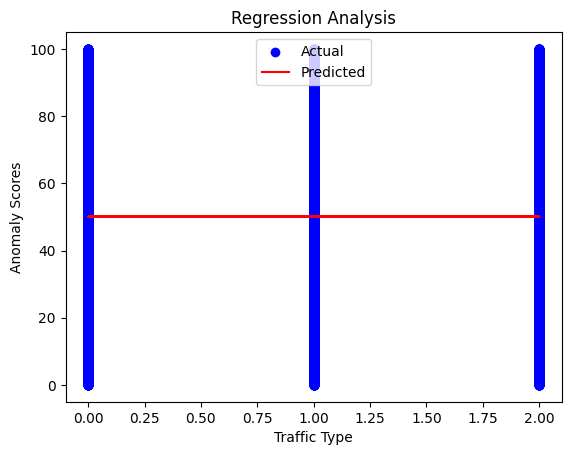

In [9]:
# Regression Analysis
def regression_analysis(df):
    df = df.dropna(subset=['Anomaly Scores'])
    X = df[['Traffic Type']]  # Selecting a feature for regression
    y = df['Anomaly Scores']
    
    le = LabelEncoder()
    X = le.fit_transform(X.values.ravel()).reshape(-1, 1)
    
    model = LinearRegression()
    model.fit(X, y)
    
    y_pred = model.predict(X)
    
    print("Regression Analysis:")
    print("Mean Squared Error:", mean_squared_error(y, y_pred))
    
    plt.scatter(X, y, color='blue', label='Actual')
    plt.plot(X, y_pred, color='red', label='Predicted')
    plt.xlabel('Traffic Type')
    plt.ylabel('Anomaly Scores')
    plt.title('Regression Analysis')
    plt.legend()
    plt.show()
regression_analysis(df) # Perform regression analysis

# Predicative Analysis
Building and Evaluating a predictive model using Random Forest Classification to predict the Severity Level of cybersecurity incidents based on Traffic Type and Anomaly Scores.
1. Data Cleaning & Preprocessing - Removes missing values to ensure data quality. and it uses Label Encoding to convert categorical variables (Traffic Type & Severity Level) into numerical format for model training.
2. Feature Selection - Independent Variables (X):Traffic Type (network traffic category) and Anomaly Scores (severity of network anomalies).
Dependent Variable (y):Severity Level (the seriousness of a cybersecurity attack).
3. Model Training & Evaluation - Splits the dataset into 80% training and 20% testing using train_test_split().
Trains a Random Forest Classifier with 100 count to learn attack patterns.
Makes predictions on the test dataset and evaluates model performance using accuracy score.



In [10]:
# Predictive Model
def predictive_model(df):
    df = df.dropna()
    le = LabelEncoder()
    df['Traffic Type'] = le.fit_transform(df['Traffic Type'])
    df['Severity Level'] = le.fit_transform(df['Severity Level'])
    
    X = df[['Traffic Type', 'Anomaly Scores']]
    y = df['Severity Level']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    print("Predictive Model Accuracy:", accuracy_score(y_test, y_pred))
predictive_model(df) # Build a predictive model

Predictive Model Accuracy: 0.321625


Expected Outcome of Predicative Model
* Trains a machine learning model to predict the severity level of cybersecurity incidents.
* Displays the model's accuracy, indicating how well it performs on unseen data.
* It provides a basis for cybersecurity threat classification, aiding in risk assessment and response planning.

This predictive model can be further improved by adding more features or tuning hyperparameters for better performance.

---

Further visualisations are explained in a separate Jupyter Notebook named "SecurityBreachVisuals" for better understanding and to avoid the need to run each cell from top to bottom, which is one of the drawbacks of Jupyter Notebook.

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)
